# 08. Publication Figure 4: Cumulative Attention Budget and Satisficing

## Behavioral Economics Hypothesis
Users operate under bounded rationality (Simon's Satisficing). Rather than evaluating all 20 items, users exhaust their attention budget within the top $k$ items.


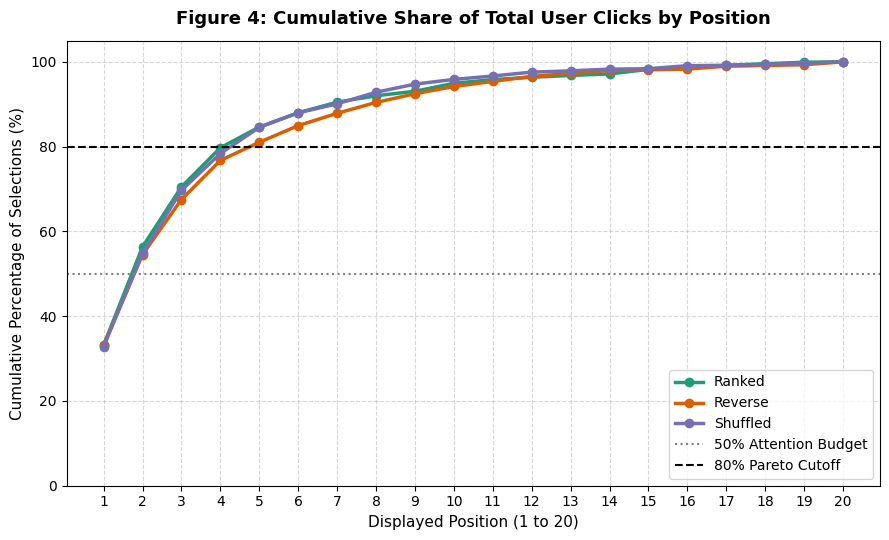

Figure 4 rendered and exported successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/mnt/data/h2_testing_dataset.csv')

# Cumulative selections across positions
cum_df = df.groupby(['condition', 'displayed_position'])['selected'].sum().reset_index()
cum_df['total_selected'] = cum_df.groupby('condition')['selected'].transform('sum')
cum_df['cum_share'] = cum_df.groupby('condition')['selected'].cumsum() / cum_df['total_selected']

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {'Ranked': '#1b9e77', 'Reverse': '#d95f02', 'Shuffled': '#7570b3'}

for cond in ['Ranked', 'Reverse', 'Shuffled']:
    sub = cum_df[cum_df['condition'] == cond]
    ax.plot(sub['displayed_position'], sub['cum_share'] * 100, label=cond, color=colors[cond], lw=2.5, marker='o')

ax.axhline(50, color='gray', linestyle=':', label='50% Attention Budget')
ax.axhline(80, color='black', linestyle='--', label='80% Pareto Cutoff')

ax.set_title("Figure 4: Cumulative Share of Total User Clicks by Position", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Displayed Position (1 to 20)", fontsize=11)
ax.set_ylabel("Cumulative Percentage of Selections (%)", fontsize=11)
ax.set_xticks(range(1, 21))
ax.set_ylim(0, 105)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/mnt/data/github_replication_suite/notebooks/figure4_cumulative_budget.png', dpi=300)
plt.show()
print("Figure 4 rendered and exported successfully.")
